# South West WA Rainfall Decline (1950–2024)
**An analysis of slow-building physical climate risk, written for AASB S2.** (AASB S2 is the Australian rule that asks big companies to report their climate risks.)

You can run the whole thing end to end. The cleaning and statistics use only `numpy`/`pandas`/`matplotlib`, and every statistical routine is coded from scratch in `stats_utils.py` and tested in `test_stats.py`. 
This notebook runs from the CSV files already saved in `data/`, so there is no raw download needed.

## 0. Statistics are correct
Hand-written statistics are only worth trusting if you can prove they work. So I run the 28 unit tests (small automatic checks) first.

In [1]:
import subprocess, sys
r = subprocess.run([sys.executable, 'test_stats.py'], capture_output=True, text=True)
print(r.stdout[-400:])
assert r.returncode == 0, 'unit tests failed'

step at 30): got 30, want 30
[PASS] Pettitt step p < 0.001 (p=4.89e-10)
[PASS] TFPW r1 (linear): got 0, want 0
[PASS] TFPW linear: prewhitening skipped, trend increasing
[PASS] TFPW p == MK p (white noise): got 0.0734411, want 0.0734411
[PASS] TFPW white noise: prewhitening skipped
[PASS] TFPW r1 (AR1 rho=0.8): got 0.608217, want 0.6082
[PASS] TFPW AR(1): prewhitening applied

28 passed, 0 failed



## 1. The data
I use seven long-running SW WA weather stations (GHCN-Daily = Bureau of Meteorology observations) and their April–October rainfall totals. Each station is measured against its own 1950–1974 baseline (its normal level in those years). The regional series is the average of the per-station % anomalies (how far each station sits above or below its own normal).

In [2]:
import pandas as pd, numpy as np
import stats_utils as su
reg = pd.read_csv('data/annual_cool_season_anomaly.csv')
clean = pd.read_csv('data/rainfall_swwa_clean.csv')
drivers = pd.read_csv('data/drivers.csv')
print('Regional series:', reg.year.min(), '-', reg.year.max(), '| stations:', sorted(clean.station.unique()))
reg.tail()

Regional series: 1950 - 2024 | stations: ['Albany', 'Cape Leeuwin', 'Deeside', 'Narrogin', 'Northam', 'Wagin', 'Westbourne']


,year,regional_cool_mm,regional_anom_pct,regional_anom_mm,n_stations
70,2020,380.316667,-32.778372,-169.123322,6
71,2021,665.900000,18.318510,86.156795,7
72,2022,486.250000,-6.435996,-40.671739,6
73,2023,440.757143,-26.442762,-138.986062,7
74,2024,456.657143,-21.260036,-123.086062,7


## 2. Step change (Pettitt)
Where does the series suddenly shift? I use the Pettitt test, which looks for the single point in time where the data jumps to a new level (it makes no assumptions about the shape of the data).

The mm figures below are **composition-adjusted**: the raw regional mm average mixes whichever 5-7 stations reported in a year, so a year missing a wet station (Cape Leeuwin, 897 mm baseline) reads spuriously dry. Rescaling the full-network baseline by the % anomaly series (which compares each station only with itself) fixes that; it moves the drop by about two percentage points.

In [3]:
import analysis
pct = reg.regional_anom_pct.values
pt = su.pettitt(pct)
cp_year = int(reg.year.iloc[pt.cp_index])
mm_adj = analysis.adjusted_mm(reg, clean)
reg_adj = reg.assign(mm_adj=mm_adj)
pre = reg_adj[reg_adj.year < cp_year].mm_adj.mean()
post = reg_adj[reg_adj.year >= cp_year].mm_adj.mean()
pre_raw = reg[reg.year < cp_year].regional_cool_mm.mean()
post_raw = reg[reg.year >= cp_year].regional_cool_mm.mean()
print(f'Change point ~ {cp_year} (K={pt.K:.0f}, p={pt.pvalue:.4f})')
print(f'{int(reg.year.min())}-{cp_year-1}: {pre:.0f} mm  ->  {cp_year}-{int(reg.year.max())}: {post:.0f} mm  ({100*(post-pre)/pre:+.1f}%)  [composition-adjusted]')
print(f'{int(reg.year.min())}-{cp_year-1}: {pre_raw:.0f} mm  ->  {cp_year}-{int(reg.year.max())}: {post_raw:.0f} mm  ({100*(post_raw-pre_raw)/pre_raw:+.1f}%)  [raw station mix]')

Change point ~ 2000 (K=642, p=0.0061)
1950-1999: 567 mm  ->  2000-2024: 483 mm  (-14.8%)  [composition-adjusted]
1950-1999: 571 mm  ->  2000-2024: 475 mm  (-16.9%)  [raw station mix]


## 3. Trend (Mann-Kendall + Sen + OLS)
Is rainfall trending down over the whole period? I use three tests: Mann-Kendall (checks whether a trend is real), Sen's slope (a robust estimate of how steep it is), and OLS (ordinary least squares, the standard straight-line fit). Every Mann-Kendall p-value is also re-run with trend-free prewhitening (`mk_p_tfpw`, a standard correction for year-to-year carry-over in a series); the series here carry almost no autocorrelation, so it changes nothing, but the check is what makes the plain p-values trustworthy.

The table also holds the before-and-after rows: the trend is flat **before** 2000 and flat **after** 2000. Flat, drop, flat is what justifies calling this a step rather than a slope.

In [4]:
x = reg.year.values.astype(float)
mk = su.mann_kendall(pct); sen,_ = su.sens_slope(x, pct); ols = su.linregress(x, pct)
print(f'Apr-Oct: Sen {sen*10:+.1f}%/decade | OLS {ols.slope*10:+.1f}%/decade (p={ols.pvalue:.4f}) | MK {mk.trend} (tau={mk.tau:.2f}, p={mk.pvalue:.4f})')
trend = pd.read_csv('data/trend_summary.csv')
trend[['series','n','sen_slope_per_decade','ols_slope_per_decade','ols_p','mk_p','mk_p_tfpw','mk_trend']]

Apr-Oct: Sen -2.7%/decade | OLS -2.9%/decade (p=0.0005) | MK decreasing (tau=-0.25, p=0.0012)


,series,n,sen_slope_per_decade,ols_slope_per_decade,ols_p,mk_p,mk_p_tfpw,mk_trend
0,AprOct_pct_full_1950_2024,75,-2.661331,-2.882606,0.000500,0.001240,0.001240,decreasing
1,AprOct_mm_full_1950_2024,75,-18.471215,-19.895523,0.000052,0.000087,0.000087,decreasing
2,AprOct_pct_pre_2000,50,-0.675839,-1.020925,0.485236,0.712833,0.712833,no trend
3,AprOct_pct_post_2000,25,-2.401336,-0.084638,0.983402,0.657227,0.657227,no trend
4,MayJul_pct_full_1950_2024,75,-3.987108,-4.351048,0.000023,0.000131,0.000131,decreasing
5,station_Albany_mm,68,-14.453134,-15.281171,0.021687,0.029586,0.029586,decreasing
6,station_Cape Leeuwin_mm,73,-40.416484,-41.829185,0.000002,0.000007,0.000007,decreasing
7,station_Deeside_mm,73,-10.523810,-14.606057,0.012562,0.034070,0.034070,decreasing
8,station_Narrogin_mm,71,-11.300000,-12.716438,0.004383,0.009031,0.009031,decreasing
9,station_Northam_mm,71,-11.758621,-12.583405,0.004112,0.009707,0.009707,decreasing


## 4. Drivers (illustrative, **not** causal)
Here I look at how the rainfall lines up with three climate patterns: IOD, SAM and ENSO. I do this both on the raw numbers and after detrending. Detrending strips out the shared long-term decline so you can see the year-to-year wobble on its own. The detrended links are modest, which is why I call this an association, not proof of cause.

In [5]:
pd.read_csv('data/driver_correlation.csv')

,driver,n_years,period,pearson_r_raw,p_raw,pearson_r_detrended,p_detrended
0,IOD (DMI),75,1950-2024,-0.405337,0.000309,-0.255817,0.026744
1,SAM (Marshall),68,1957-2024,-0.310496,0.009967,-0.197483,0.106476
2,ENSO (Nino3.4),75,1950-2024,-0.407884,0.000281,-0.349139,0.002140


## 5. Charts
Rebuild all five figures from the saved CSV files, then show them.

Wrote 5 charts to charts/


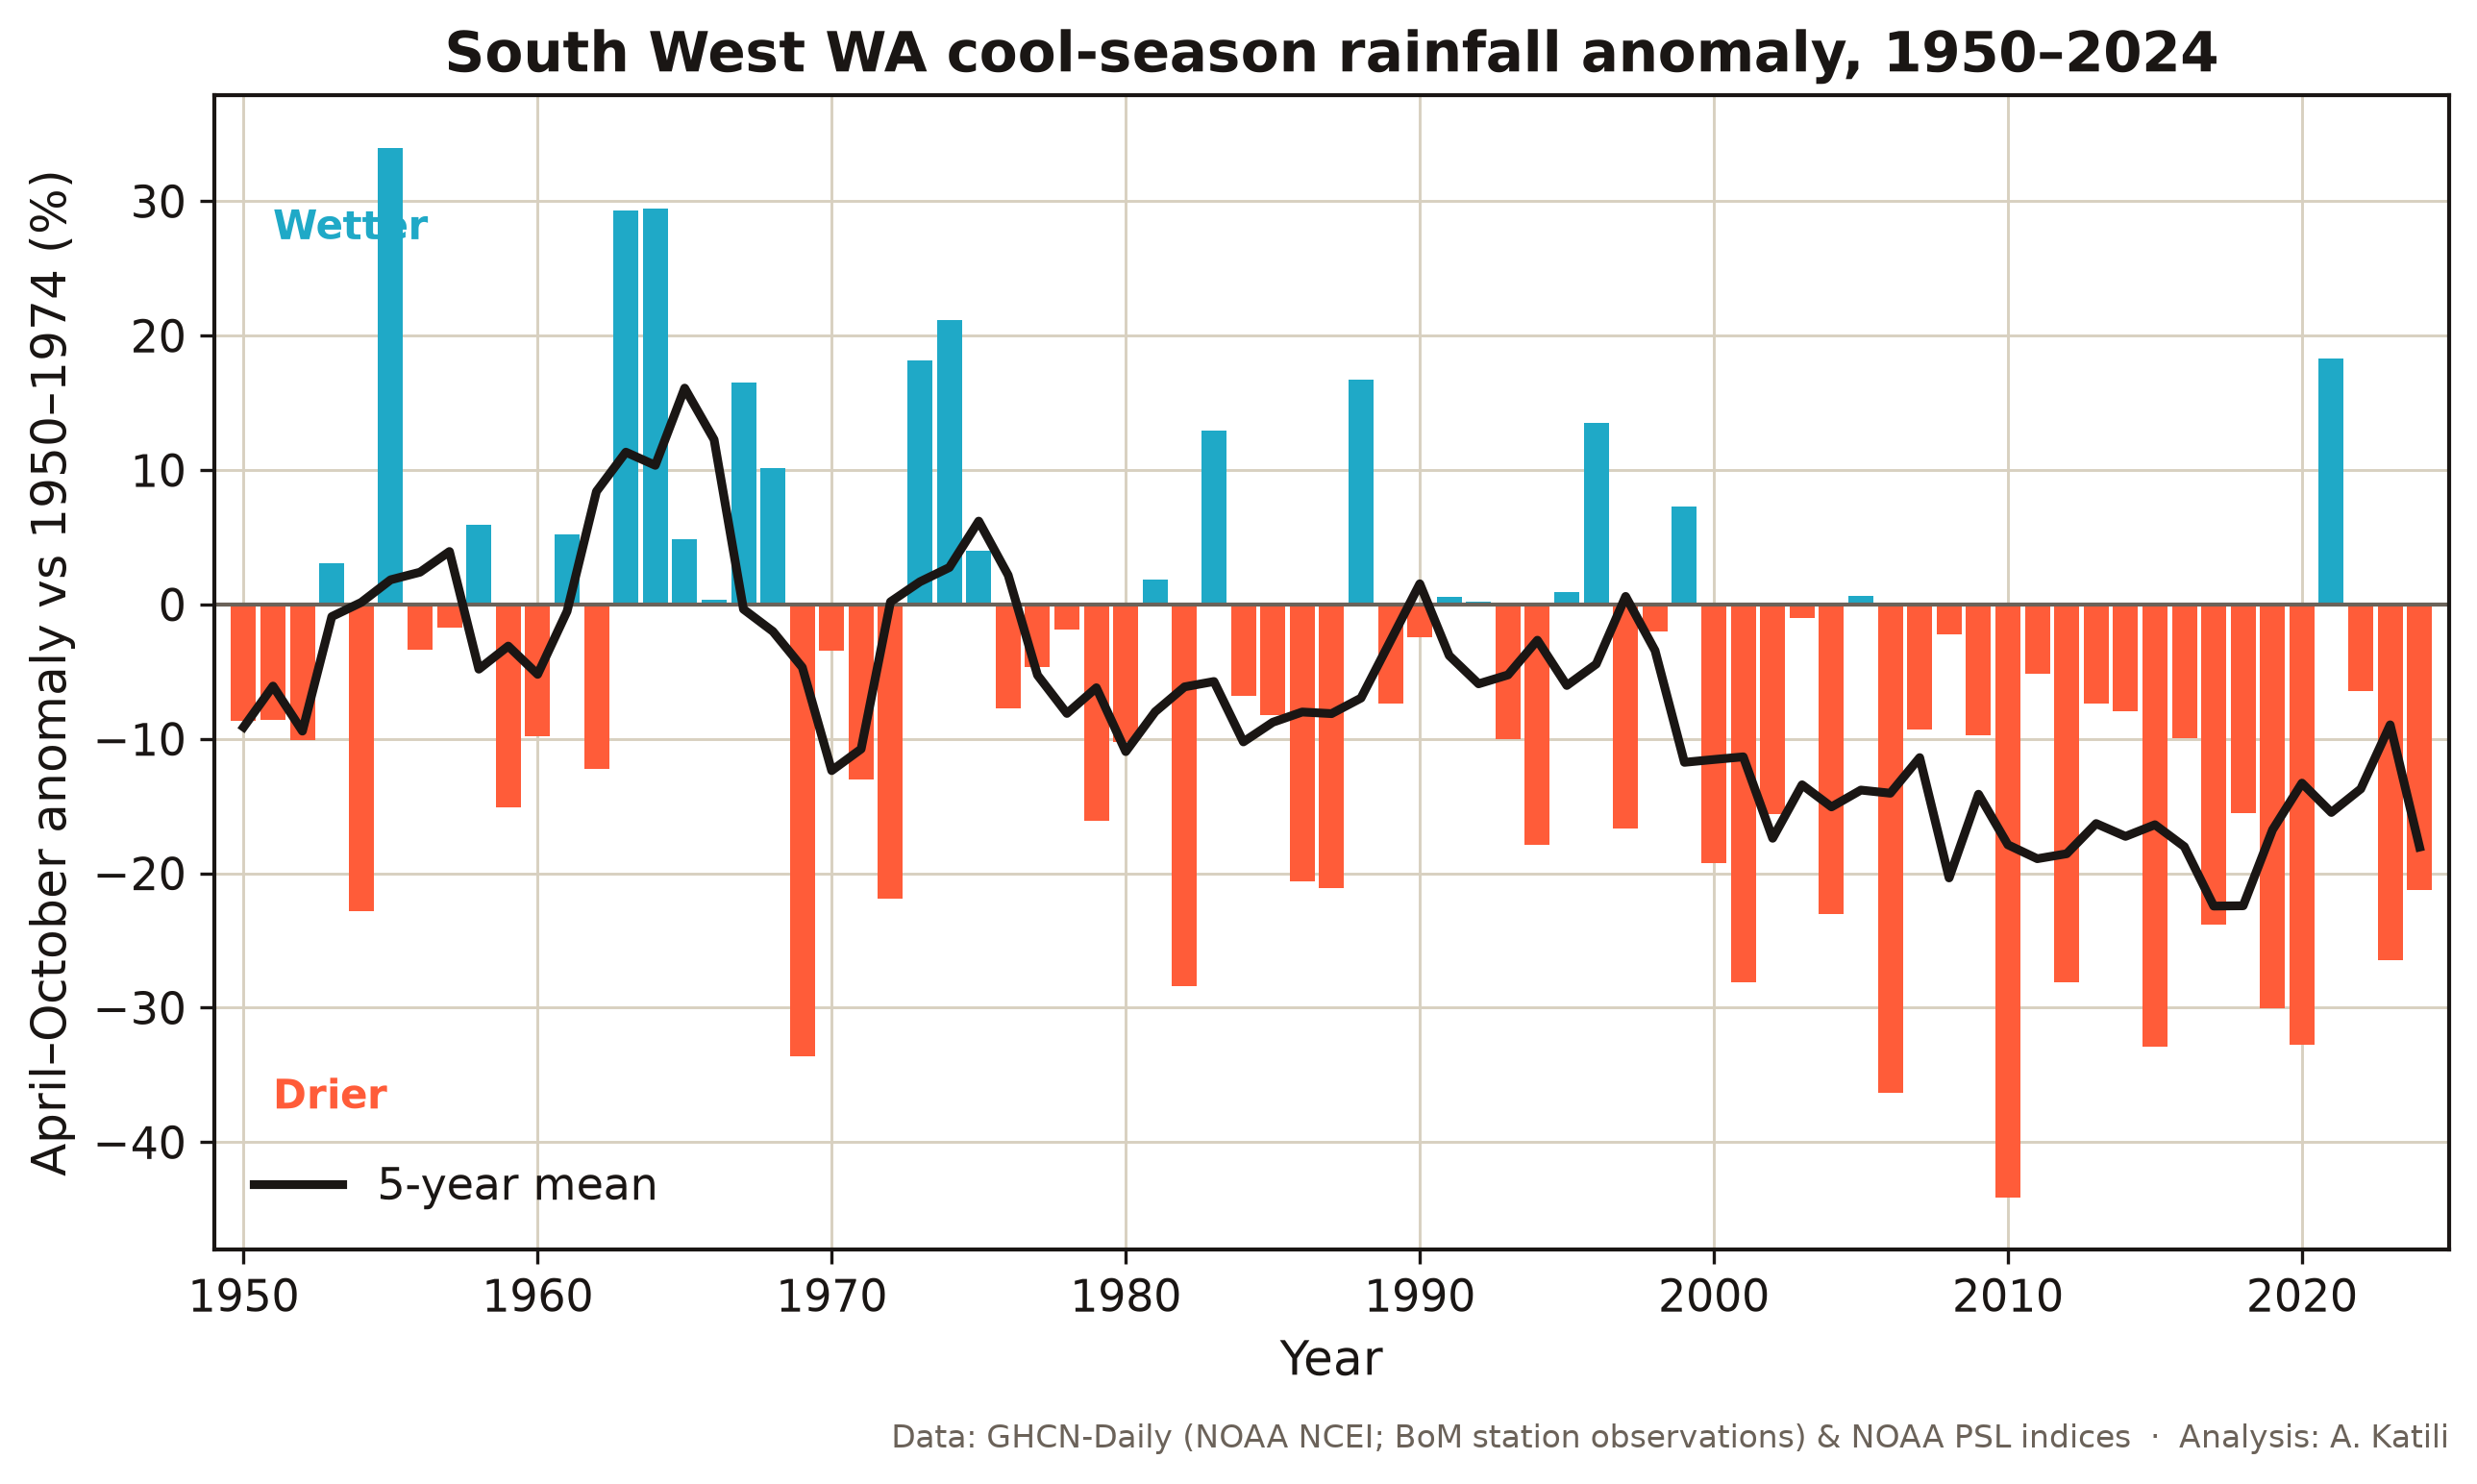

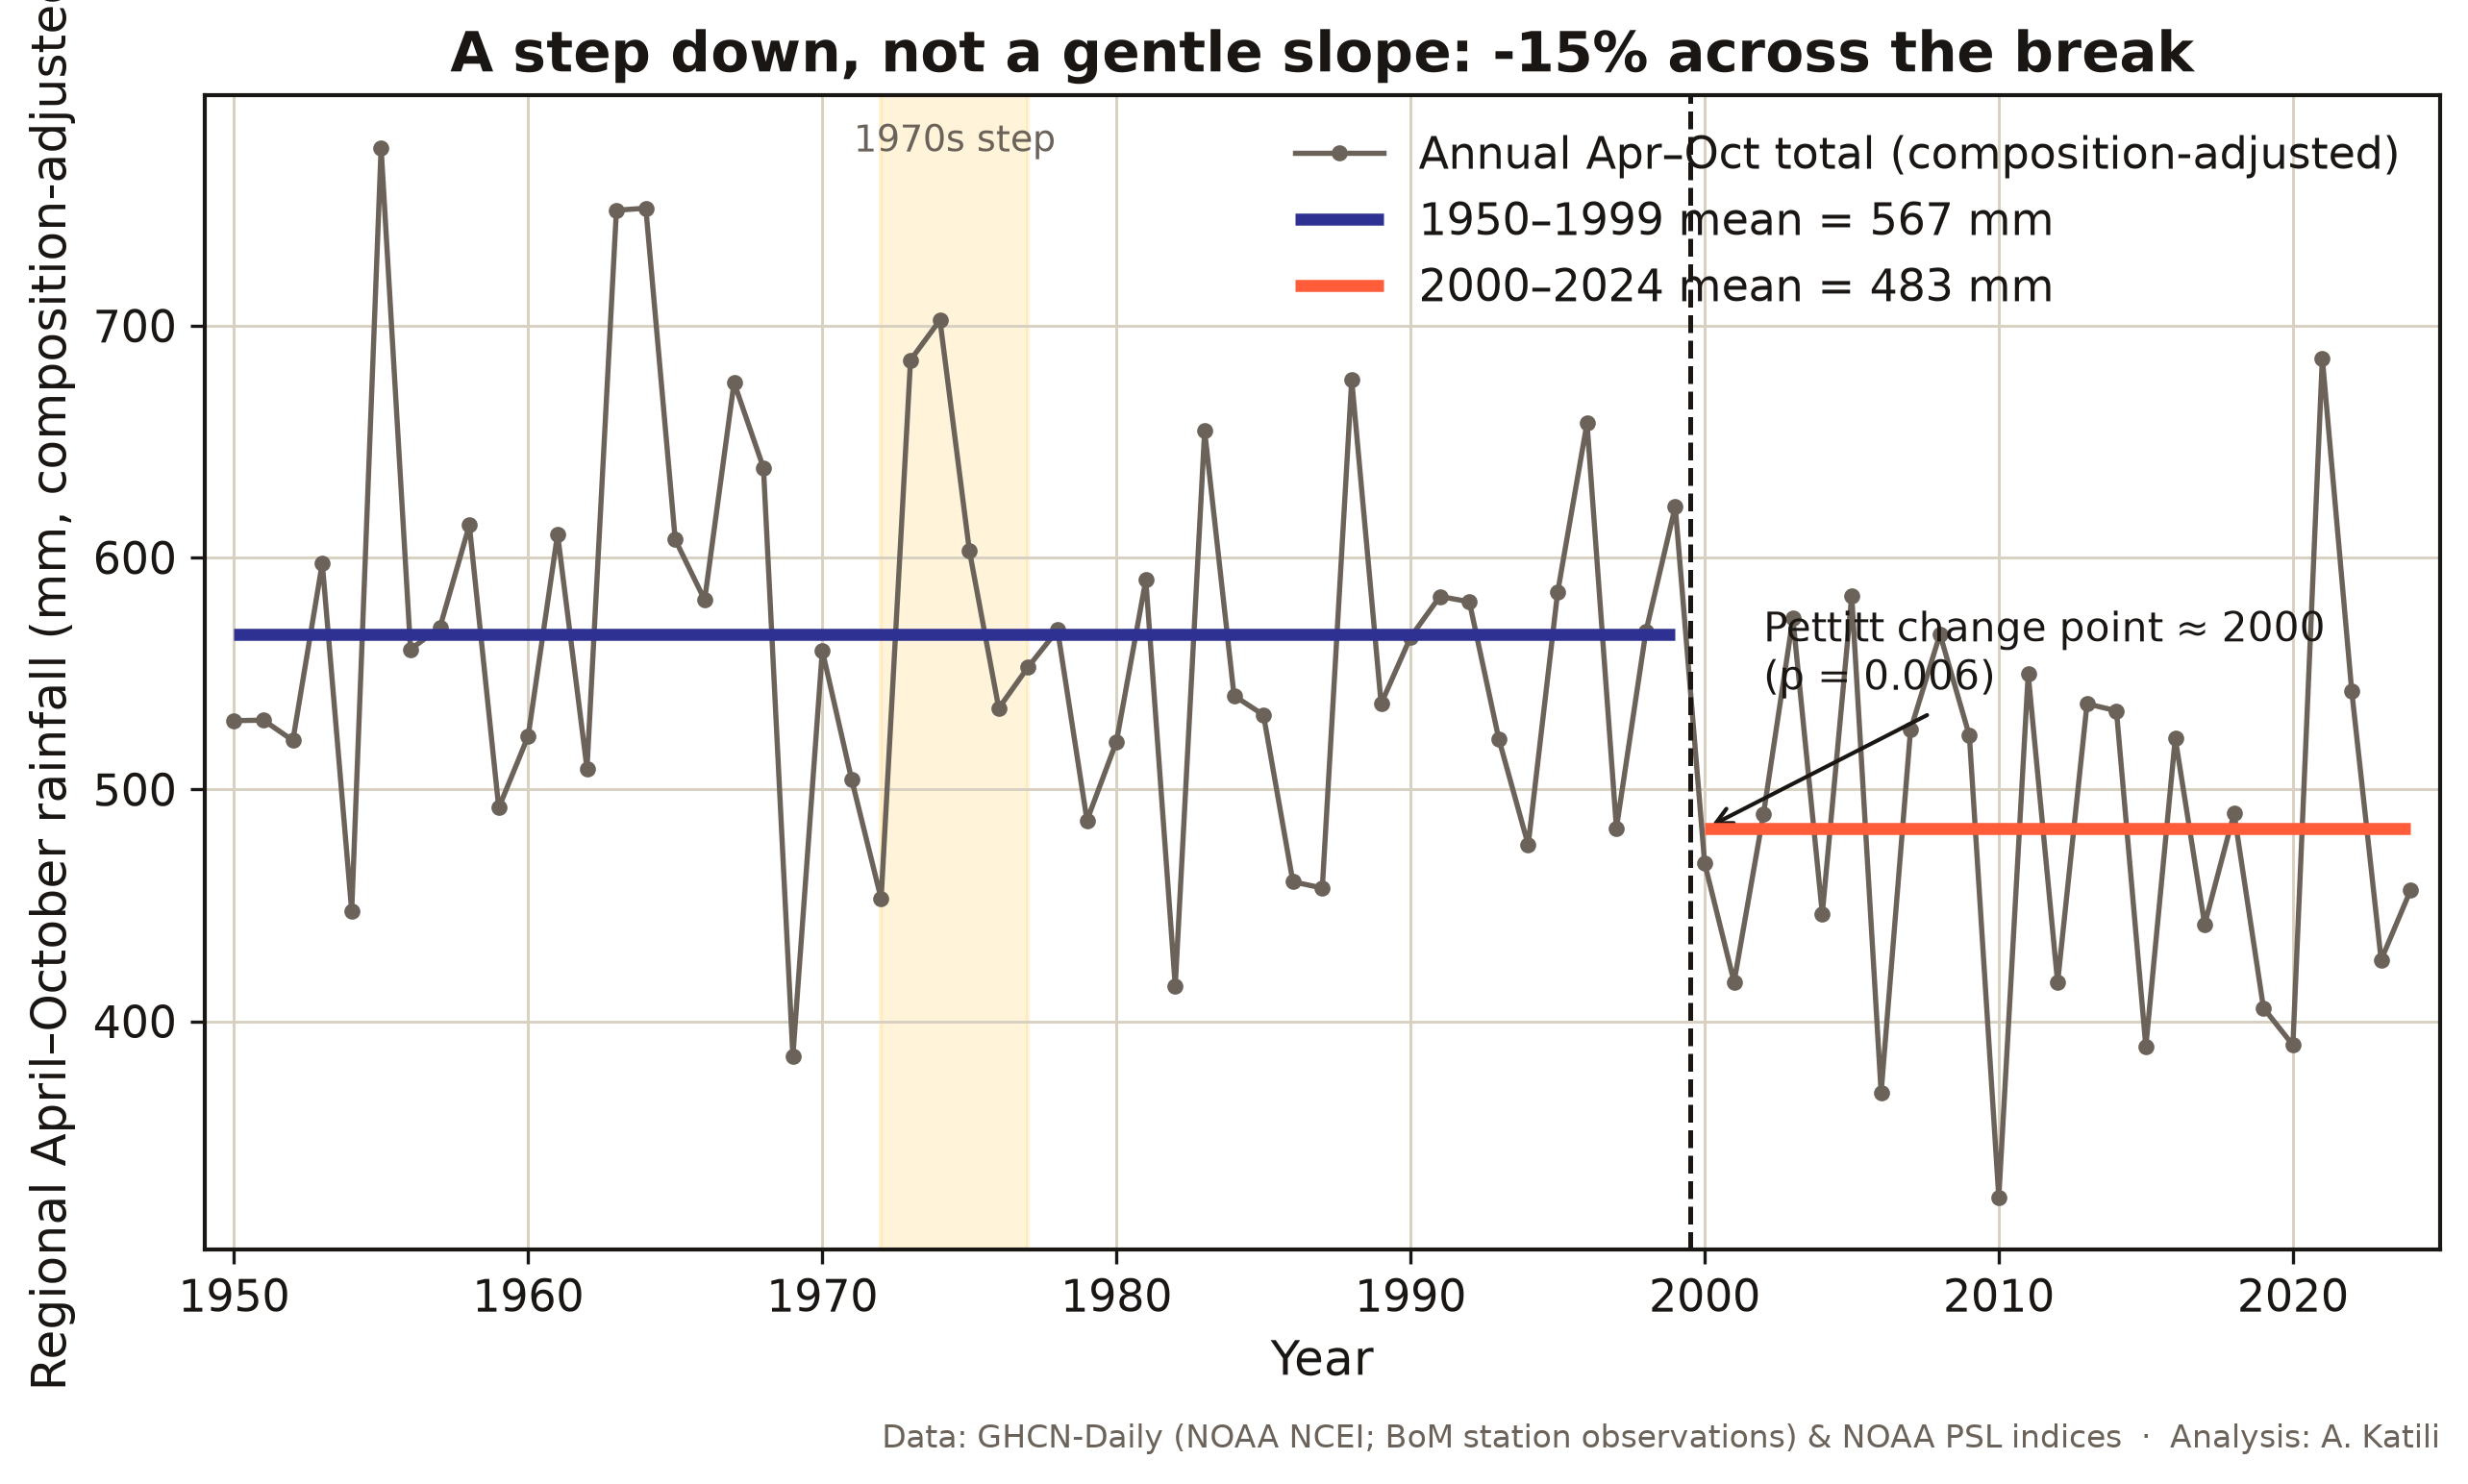

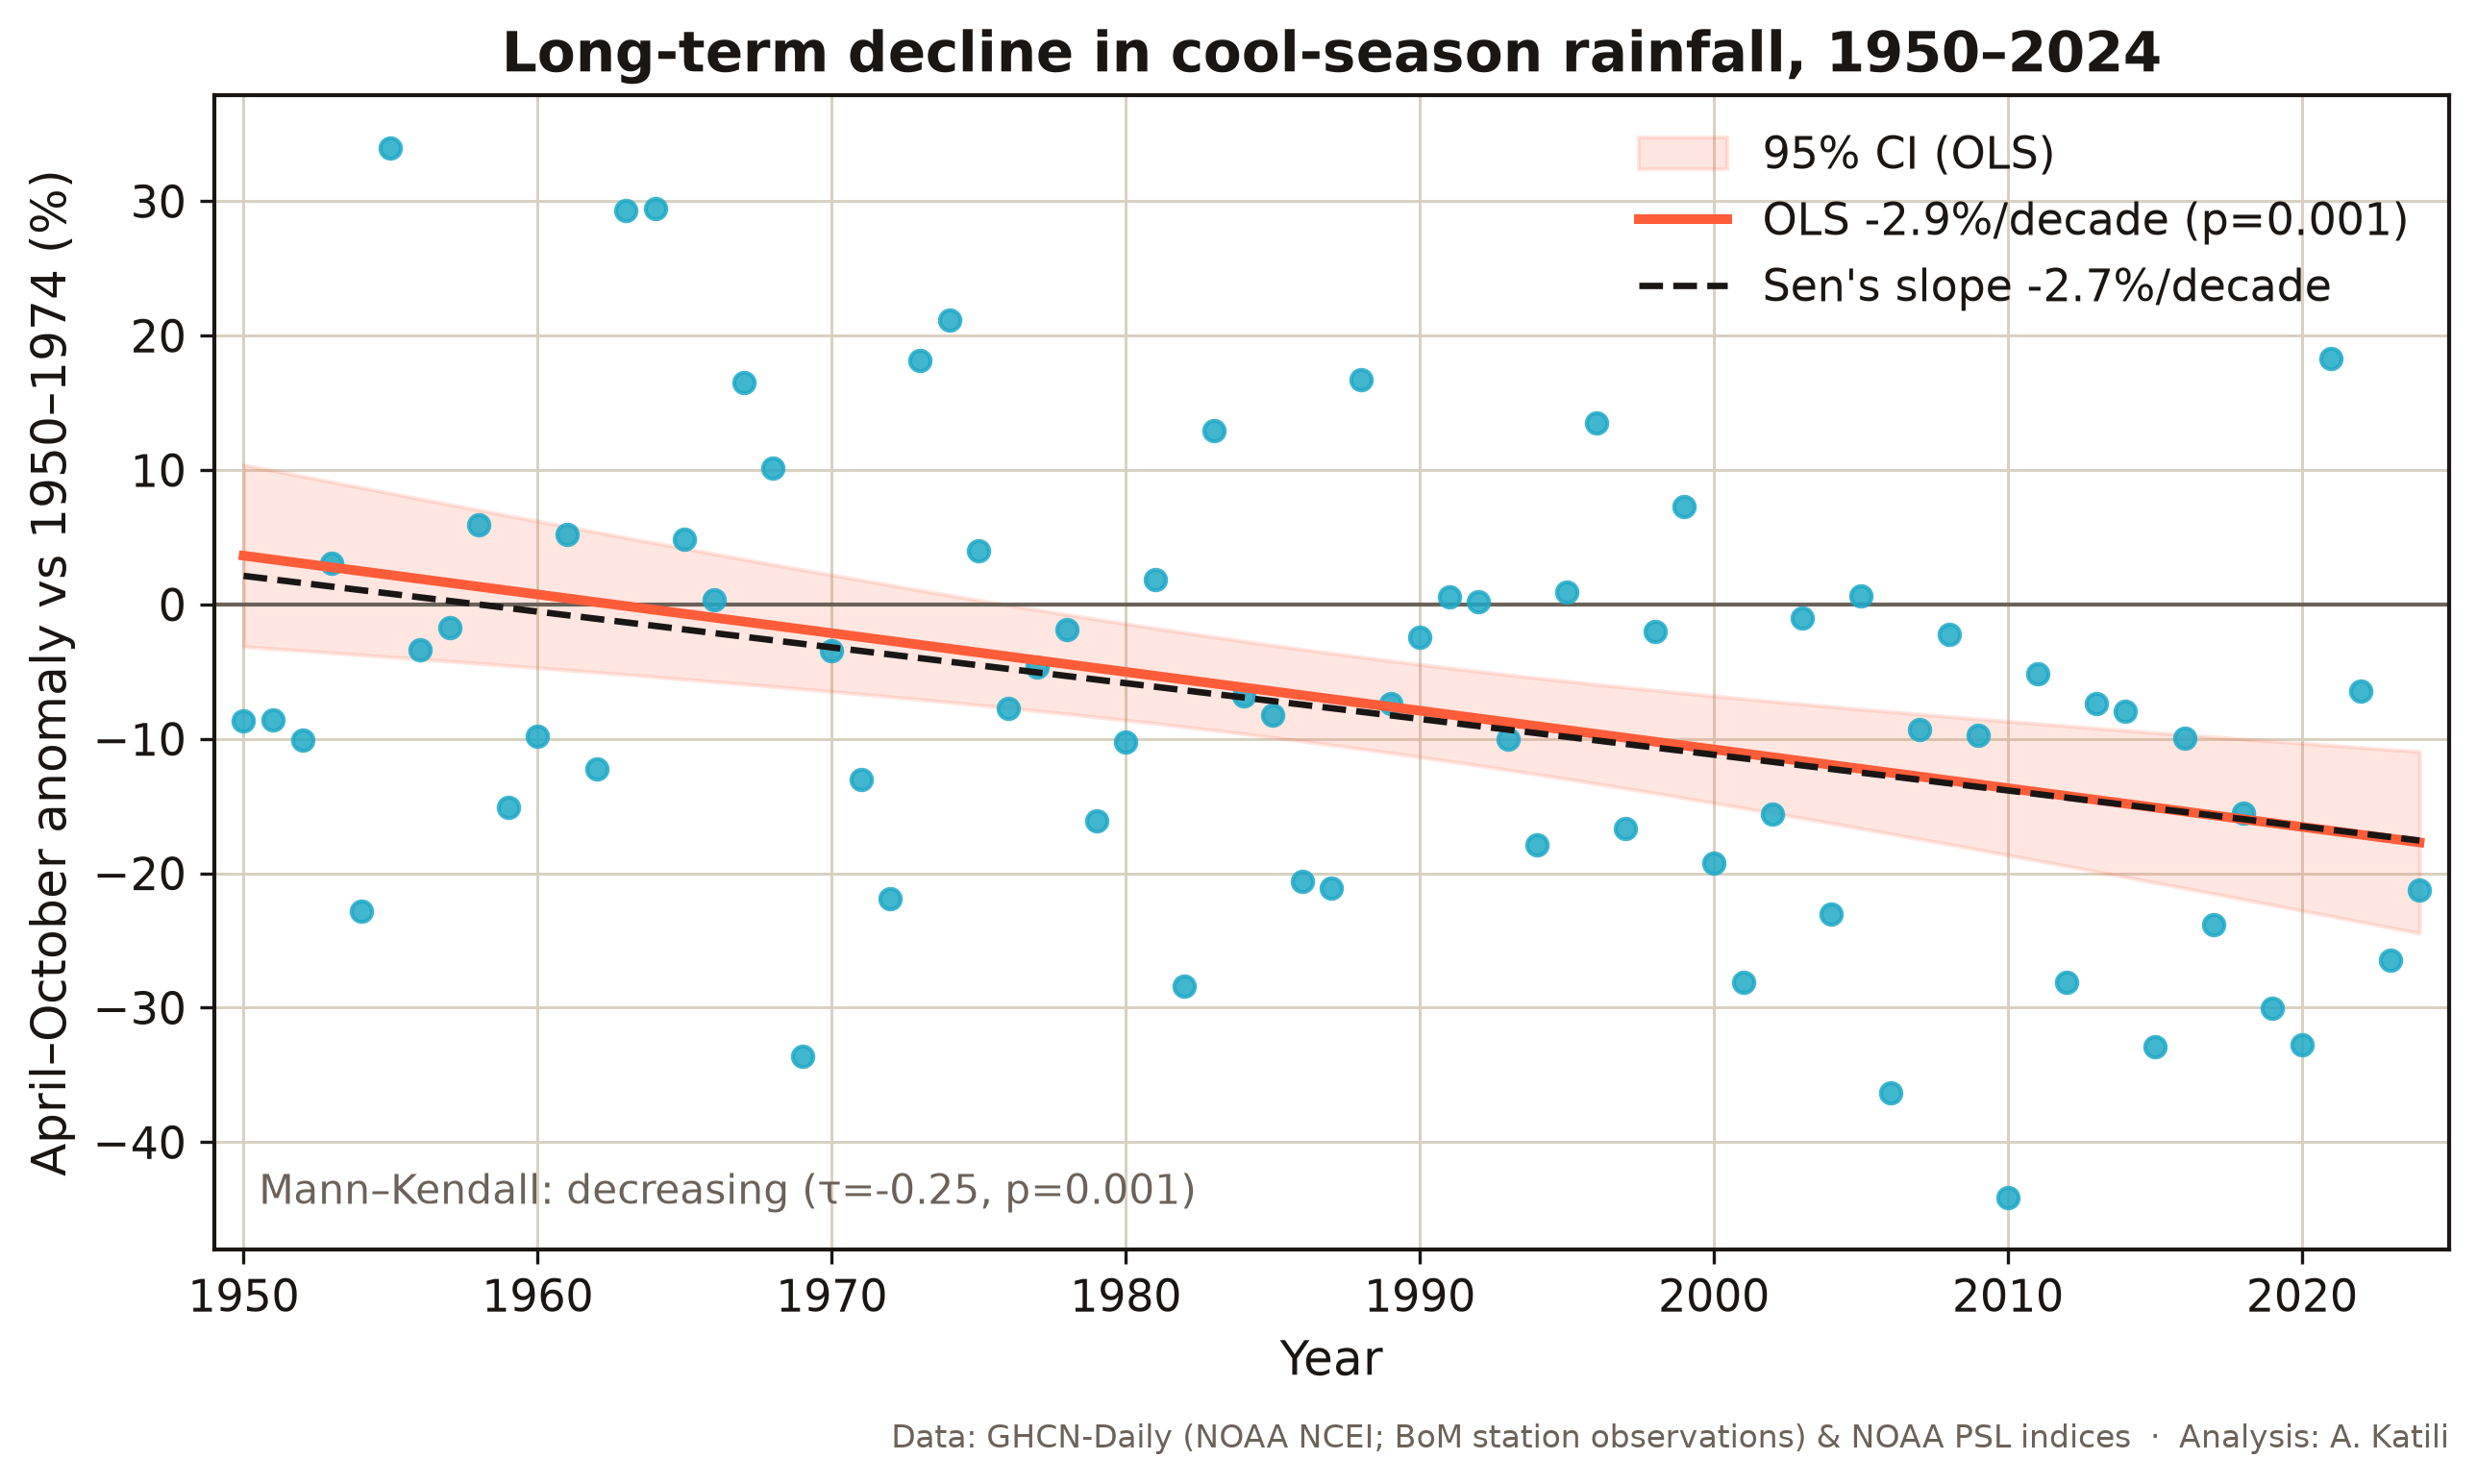

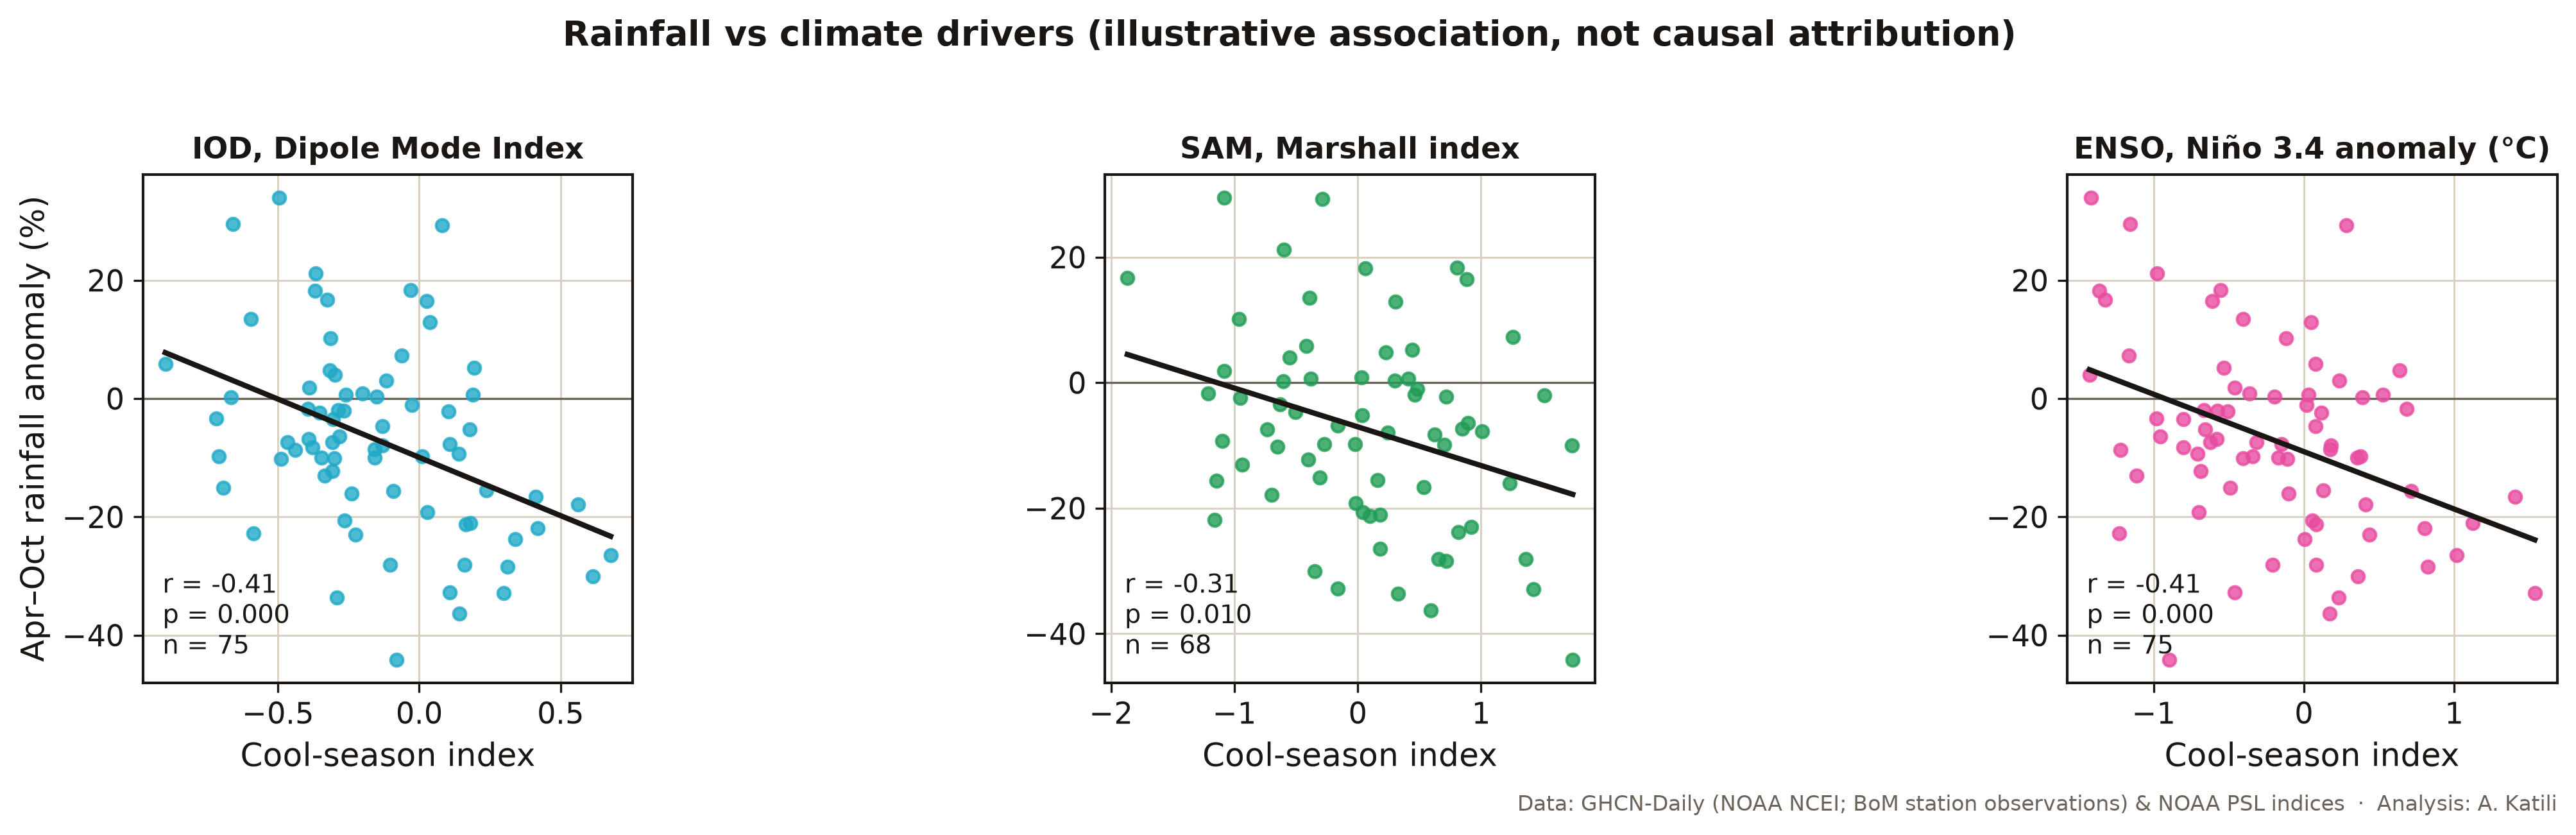

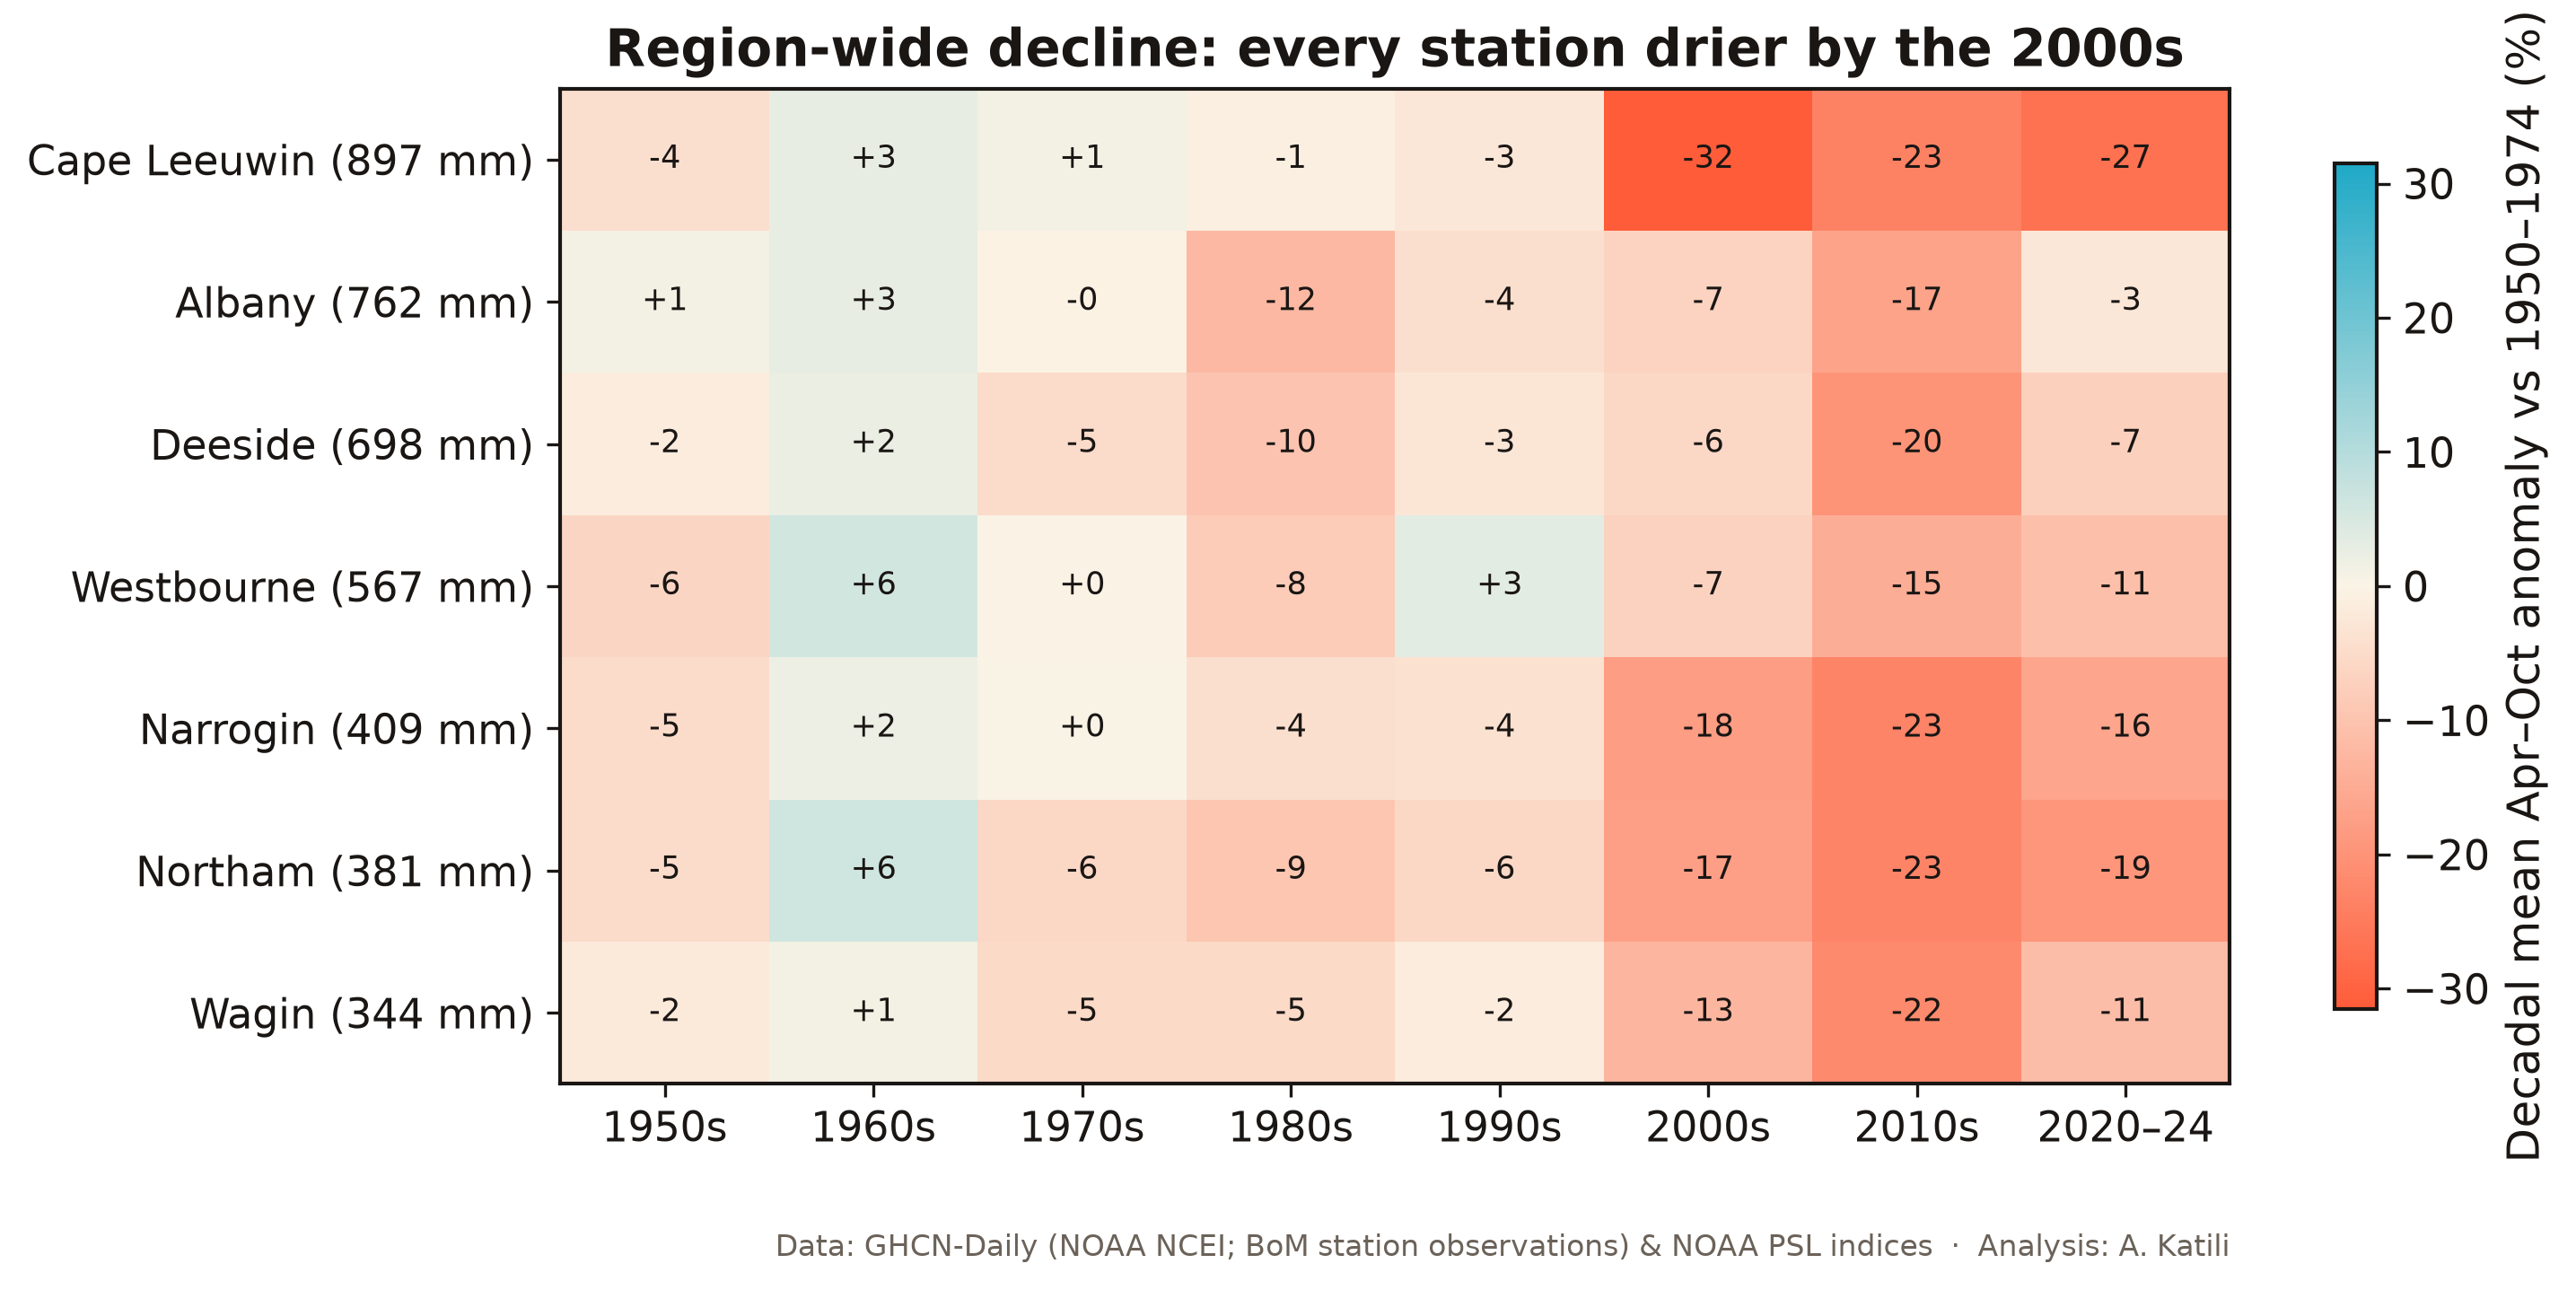

In [6]:
import viz; viz.main()
from IPython.display import Image, display
for f in ['01_timeseries_anomaly','02_stepchange','03_trend_mannkendall','04_driver_correlation','05_station_decade']:
    display(Image(filename=f'charts/{f}.png'))

## Conclusion
Cool-season rainfall in SW WA has fallen by about 2.9%/decade since 1950. There was a clear step down around 2000 (flat before it, flat after it), which left 2000–2024 roughly 17% drier than 1950–1974 on the composition-adjusted regional series. The pattern holds across all seven stations and matches published CSIRO/BoM figures. The decline itself is solid. The likely causes (a stronger subtropical ridge and a poleward shift in the storm track, driven by greenhouse gases and ozone) are summarised, with references, in the README. This is a textbook AASB S2 chronic physical risk: a permanent shift to a drier baseline.